In [26]:
from skimage.io import imread
import numpy as np
from scipy.io import loadmat
from matplotlib import pyplot as plt
import time
import os

In [27]:
from google.colab import drive
drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive/Uni/ImageProcessing')
rootfolder = 'Colab Students - Assignments/data'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Useful function for plot a 2D dictionary

In [28]:
def get_dictionary_img(D):
    M, N = D.shape
    p = int(round(np.sqrt(M)))
    nnn = int(np.ceil(np.sqrt(N)))
    bound = 2
    img = np.ones((nnn*p+bound*(nnn-1), nnn*p+bound*(nnn-1)))
    for i in range(N):
        m = np.mod(i, nnn)
        n = int((i-m)/nnn)
        m = m * p + bound * m
        n = n * p + bound * n
        atom = D[:, i].reshape((p, p))
        if atom.min() < atom.max():
            atom = (atom - atom.min()) / (atom.max() - atom.min())
        img[m: m + p, n: n + p] = atom

    return img

Define a function that implements the OMP

In [29]:
def OMP(s, D, L, tau, maxiter = 10000):
  M,N = D.shape
  x = np.zeros(N)
  i = 0
  r = s.copy()
  w = []
  while np.linalg.norm(r) > tau and len(w) < L and i < maxiter:

        # Match
        epsilon = np.abs(np.dot(D.T, r))
        jstar = np.argmax(epsilon)

        # Update w
        if jstar not in w:
            w.append(jstar)

        # Least squares update
        D_omega = D[:, w]
        x_omega, _, _, _ = np.linalg.lstsq(D_omega, s, rcond=None)

        #sparse vector and residual
        x = np.zeros(N)
        x[w] = x_omega
        r = s - np.dot(D, x)

        i += 1

  return x

## Dictionary Learning

Load the image and rescale it in $[0,1]$

In [30]:
path_image = f'{rootfolder}/barbara.png'  #  barbara.png, cameraman.png, Lena512.png

img = imread(path_image) / 255

imsz = img.shape

# patch size
p = 8

# number of elements in the patch
M = p ** 2


Extract a bunch of random patches from the image and build the training set $S$

In [31]:
npatch = 10000

S = np.zeros((M, npatch))

for i in range(npatch):
    # Random top-left coordinates
    r = np.random.randint(0, imsz[0] - p + 1)
    c = np.random.randint(0, imsz[1] - p + 1)

    # Extract and flatten patch
    patch = img[r:r+p, c:c+p]
    S[:, i] = patch.flatten()

Remove the mean from the patches (each column of $S$ must have zero-mean)

In [32]:
S = S - np.mean(S, axis=0, keepdims=True)


Define a function that implements the KSVD

In [33]:
def ksvd(S, M, N, max_iter, npatch, L, print_time=True):

    # intialize the dictionary
    D = np.random.randn(M, N)

    # normalize each column of D (zero mean and unit norm)
    # UPDATE D
    D = D - np.mean(D, axis=0)
    D = D / np.linalg.norm(D, axis=0)

    # initialize the coefficient matrix
    X = np.zeros((N, npatch))

    # Main KSVD loop
    for iter in range(max_iter):
        time_start = time.time()

        # Sparse coding step
        # perform the sparse coding via OMP of all the columns of S
        for n in range(npatch):
            X[:, n] = OMP(S[:, n], D, L, tau=0)

        # Dictionary update step
        # iterate over the columns of D
        for j in range(N):
            # find which signals uses the j-th atom in the sparse coding
            omega = np.nonzero(X[j, :])[0]

            if len(omega) == 0:
                # if the atom is never used then ignore or substitute it with a random vector
                d_new = np.random.randn(M)
                d_new = d_new - np.mean(d_new)
                D[:, j] = d_new / np.linalg.norm(d_new)
            else:
                # compute the residual matrix E, ignoring the j-th atom
                E = S - np.dot(D, X) + np.outer(D[:, j], X[j, :])

                # restrict E to the columns indicated by omega
                Eomega = E[:, omega]

                # Compute the best rank-1 approximation
                U, Sigma, V = np.linalg.svd(Eomega, full_matrices=False)

                # update the dictionary
                D[:, j] = U[:, 0]

                # update the coefficient matrix
                X[j, omega] = Sigma[0] * V[0, :]

        time_end = time.time()
        if print_time:
            print(f'Iteration {iter} runtime: {time_end-time_start}')

    return D


In [34]:
# number of columns of the dictionary
N = 256

# number of iteration of the KSVD
max_iter = 10

# maximum number of nonzero coefficients for the sparse coding
L = 4


# Call the KSVD implementation
D = ksvd(S, M, N, max_iter, npatch, L, print_time=True)

Iteration 0 runtime: 6.632017135620117
Iteration 1 runtime: 5.197354793548584
Iteration 2 runtime: 8.698978900909424
Iteration 3 runtime: 5.253139972686768
Iteration 4 runtime: 7.013145923614502
Iteration 5 runtime: 5.389769792556763
Iteration 6 runtime: 7.060808181762695
Iteration 7 runtime: 5.4432759284973145
Iteration 8 runtime: 7.319908618927002
Iteration 9 runtime: 5.481522798538208


Show the learned dictionary

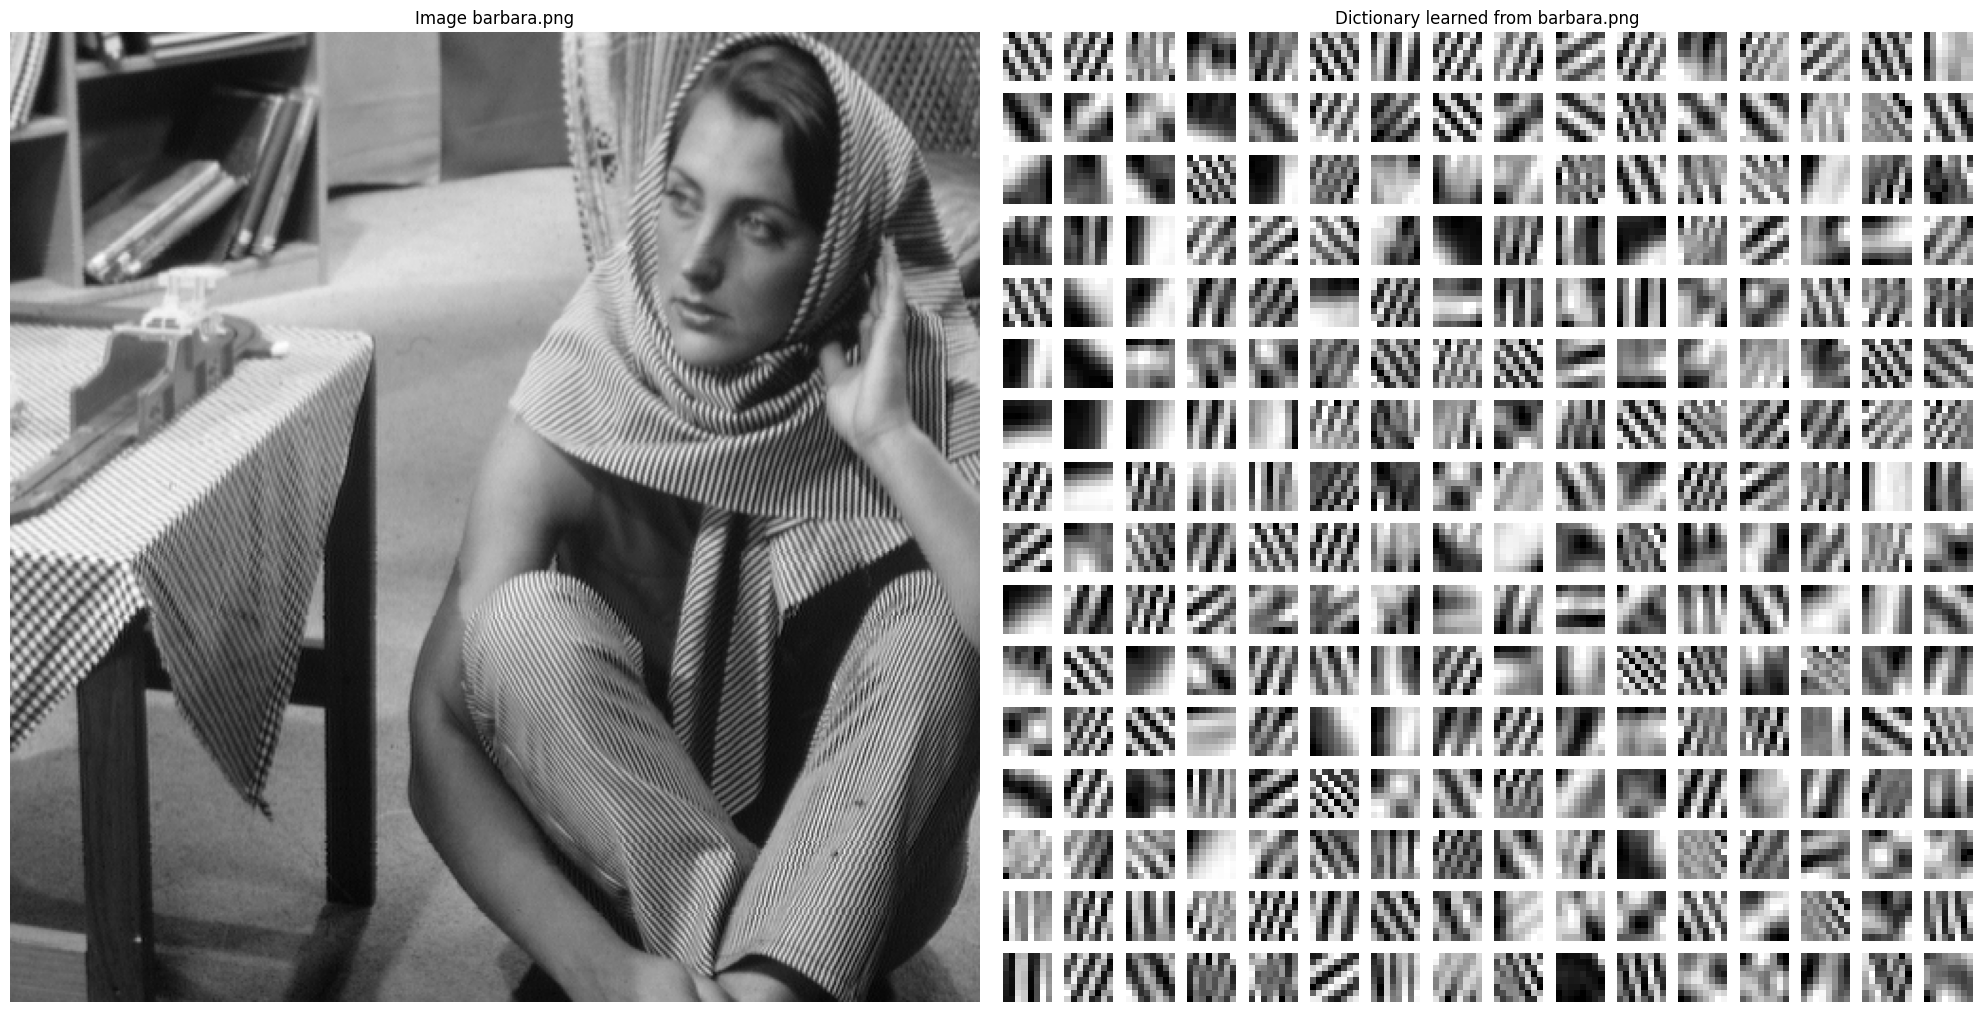

In [35]:
fig, ax = plt.subplots(1, 2, figsize=(20, 10))

ax[0].imshow(img, cmap='gray')
ax[0].set_title(f'Image {path_image.split("/")[-1]}')
ax[0].axis('off')

img_dict = get_dictionary_img(D)
ax[1].imshow(img_dict, cmap='gray')
ax[1].set_title(f'Dictionary learned from {path_image.split("/")[-1]}')
ax[1].axis('off')

plt.tight_layout()

## OMP denoising with learned dictionaries

In [36]:
img_clean = imread(f'{rootfolder}/barbara.png') / 255

# Corrupte the image

sigma_noise = 20/255
noisy_img = img_clean + sigma_noise * np.random.randn(*img_clean.shape)

In [37]:
psnr_noisy = 10 * np.log10(1 / (sigma_noise ** 2))

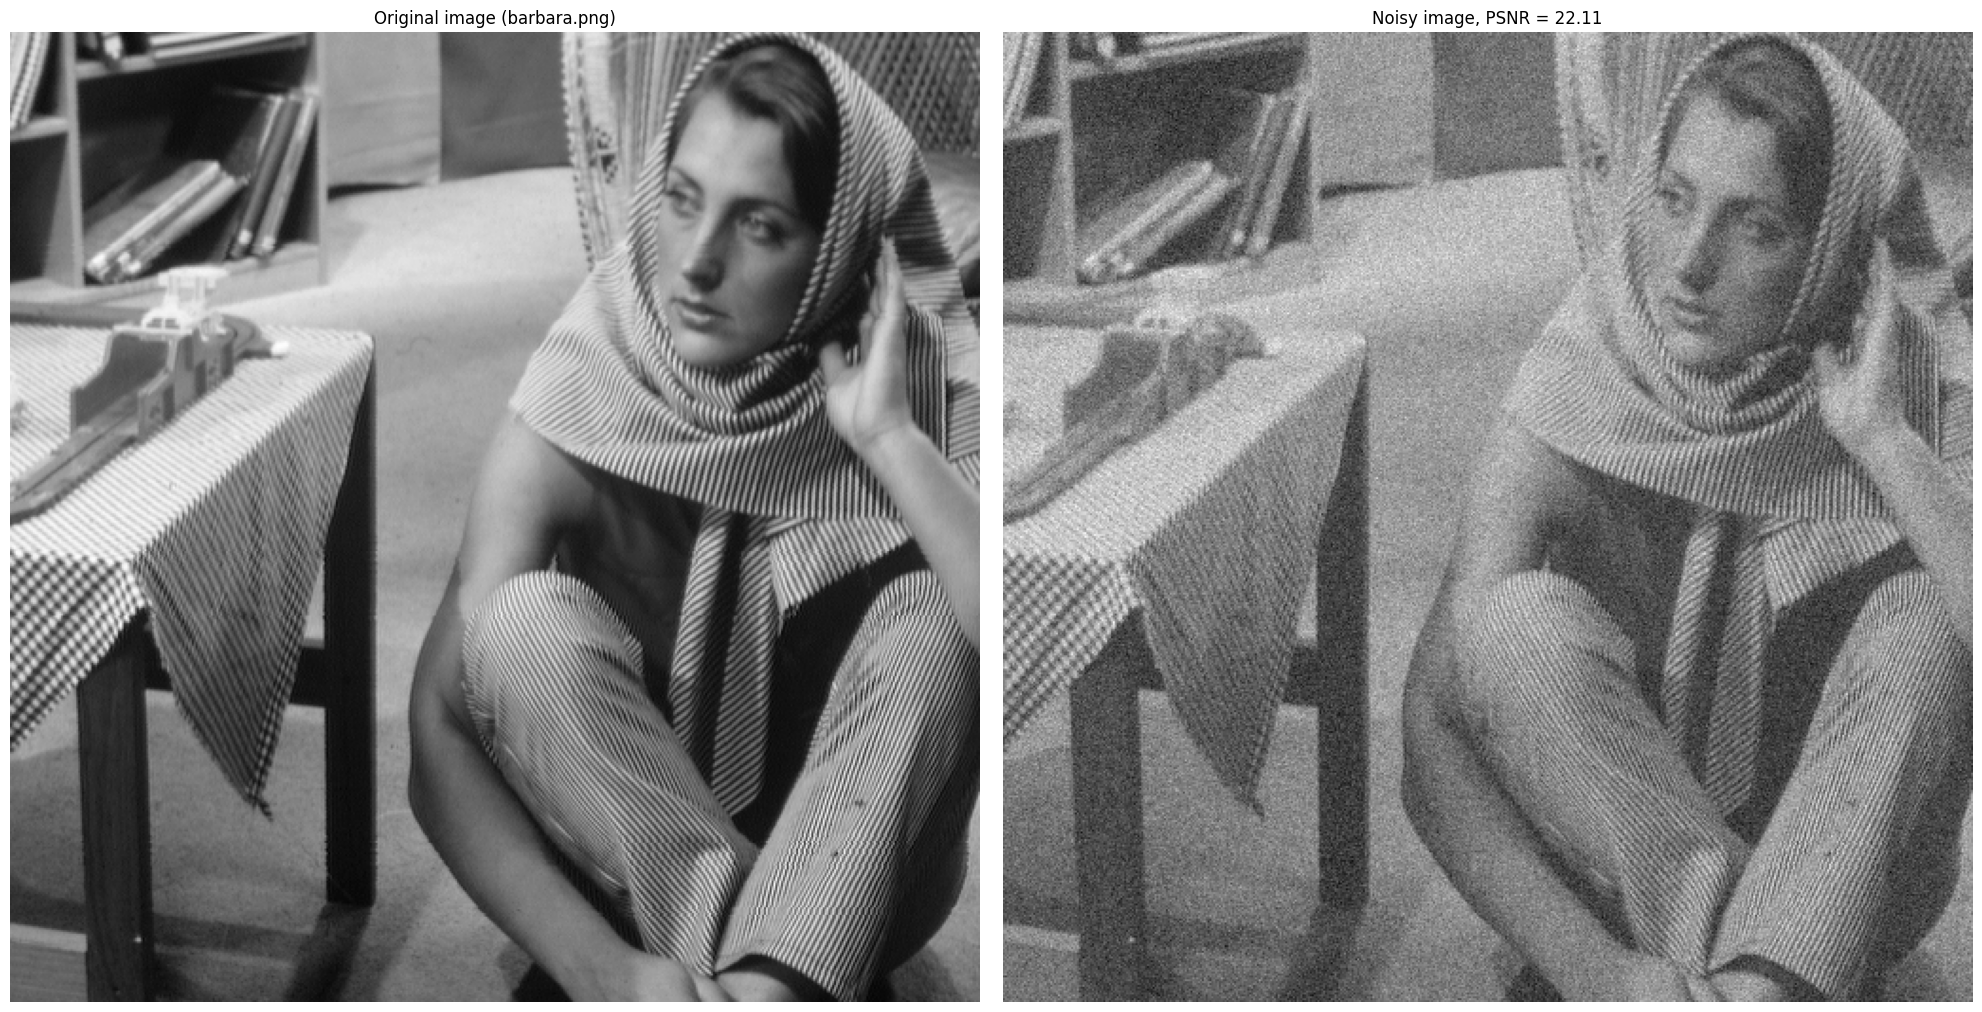

In [38]:
fig, ax = plt.subplots(1, 2, figsize=(20, 10))
ax[0].imshow(img_clean, cmap='gray')
ax[0].set_title(f'Original image (barbara.png)')
ax[0].axis('off')

ax[1].imshow(noisy_img, cmap='gray')
ax[1].set_title(f'Noisy image, PSNR = {psnr_noisy:.2f}')
ax[1].axis('off')

plt.tight_layout()


In [39]:
# patch size
p = 8

# number of elements in the patch
M = p ** 2

# number of columns of the dictionary
N = 256

# number of iteration of the KSVD
max_iter = 10

# maximum number of nonzero coefficients for the sparse coding
L = 3

Generic dictionary

In [40]:
D_generic = loadmat(f'{rootfolder}/dict_nat_img.mat')['D']

Dictionary learned from a different image

In [41]:
img = imread(f'{rootfolder}/lena.png') / 255

npatch = 10000
S = np.zeros((M, npatch))
h, w = img.shape

for i in range(npatch):
    # Random top-left coordinates
    r = np.random.randint(0, h - p + 1)
    c = np.random.randint(0, w - p + 1)

    # Extract and flatten patch
    patch = img[r:r+p, c:c+p]
    S[:, i] = patch.flatten()

# Remove mean
S = S - np.mean(S, axis=0, keepdims=True)

# Learn dictionary
D_diff = ksvd(S, M, N, max_iter, npatch, L)

FileNotFoundError: No such file: '/content/drive/MyDrive/Uni/ImageProcessing/Colab Students - Assignments/data/lena.png'

Dictionary learned from the noisy image

In [ ]:
npatch = 10000
S = np.zeros((M, npatch))
h, w = noisy_img.shape

for i in range(npatch):
    # Random top-left coordinates
    r = np.random.randint(0, h - p + 1)
    c = np.random.randint(0, w - p + 1)

    # Extract and flatten patch
    patch = noisy_img[r:r+p, c:c+p]
    S[:, i] = patch.flatten()

S = S - np.mean(S, axis=0, keepdims=True)

# Learn  the dictionary
D_noisy = ksvd(S, M, N, max_iter, npatch, L)

Dictionary learned from the clean image

In [ ]:
# Extract random patches
npatch = 10000
S = np.zeros((M, npatch))
h, w = img_clean.shape

for i in range(npatch):
    # Random top-left coordinates
    r = np.random.randint(0, h - p + 1)
    c = np.random.randint(0, w - p + 1)

    # Extract and flatten patch
    patch = img_clean[r:r+p, c:c+p]
    S[:, i] = patch.flatten()

# Remove mean
S = S - np.mean(S, axis=0, keepdims=True)

# Learn dictionary
D_clean = ksvd(S, M, N, max_iter, npatch, L)

OMP denoising

In [ ]:
def omp_denoising(noisy_img, D, step, tau):
    imsz = noisy_img.shape
    img_hat = np.zeros(imsz)
    weights = np.zeros(imsz)

    M, N = D.shape
    p = int(np.sqrt(M))

    for i in range(0, imsz[0] - p + 1, step):
        for j in range(0, imsz[1] - p + 1, step):

            # Extract and flatten patch
            s = noisy_img[i: i + p, j: j + p].reshape(-1)

            # Center patch
            s_mean = np.mean(s)
            s = s - s_mean

            # Sparse coding
            x = OMP(s, D, L, tau)

            # Reconstruct and add mean
            s_hat = np.dot(D, x) + s_mean

            # Accumulate reconstructed patch and weights
            img_hat[i: i + p, j: j + p] += s_hat.reshape(p, p)
            weights[i: i + p, j: j + p] += 1

    # Average overlapping patches
    img_hat = img_hat / np.maximum(weights, 1)

    img_hat = np.clip(img_hat, 0, 1)

    return img_hat

Denoising using the learned dictionaries

In [ ]:
# set the threshold
tau = 1.15 * p * sigma_noise

# define the step (=p for non overlapping paches)
STEP = 4 # STEP = 1 might be very time consuming, start with larger STEP

Solve the four denoising problems

In [ ]:
# Denoising with dictionary D_generic
img_hat_generic = omp_denoising(noisy_img, D_generic, STEP, tau)

# Denoising with dictionary D_diff
img_hat_diff = omp_denoising(noisy_img, D_diff, STEP, tau)

# Denoising with dictionary D_noisy
img_hat_noisy = omp_denoising(noisy_img, D_noisy, STEP, tau)

# Denoising with dictionary D_clean
img_hat_clean = omp_denoising(noisy_img, D_clean, STEP, tau)

Visualize the results

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(20, 10))
ax[0].imshow(get_dictionary_img(D_generic), cmap='gray')
ax[0].set_title('Dictionary (Generic)')
ax[0].axis('off')

mse = np.mean((img_clean - img_hat_generic) ** 2)
psnr_hat = 10 * np.log10(1 / mse)

ax[1].imshow(img_hat_generic, cmap='gray')
ax[1].set_title(f'Denoised image, PSNR = {psnr_hat:.2f}')
ax[1].axis('off')

plt.tight_layout()

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(20, 10))
ax[0].imshow(get_dictionary_img(D_diff), cmap='gray')
ax[0].set_title('Dictionary (From a different image)')
ax[0].axis('off')

mse = np.mean((img_clean - img_hat_diff) ** 2)
psnr_hat = 10 * np.log10(1 / mse)

ax[1].imshow(img_hat_diff, cmap='gray')
ax[1].set_title(f'Denoised image, PSNR = {psnr_hat:.2f}')
ax[1].axis('off')

plt.tight_layout()

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(20, 10))
ax[0].imshow(get_dictionary_img(D_noisy), cmap='gray')
ax[0].set_title('Dictionary (From the noisy image)')
ax[0].axis('off')

mse = np.mean((img_clean - img_hat_noisy) ** 2)
psnr_hat = 10 * np.log10(1 / mse)

ax[1].imshow(img_hat_noisy, cmap='gray')
ax[1].set_title(f'Denoised image, PSNR = {psnr_hat:.2f}')
ax[1].axis('off')

plt.tight_layout()

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(20, 10))
ax[0].imshow(get_dictionary_img(D_clean), cmap='gray')
ax[0].set_title('Dictionary (from the clean image)')
ax[0].axis('off')

mse = np.mean((img_clean - img_hat_clean) ** 2)
psnr_hat = 10 * np.log10(1 / mse)

ax[1].imshow(img_hat_clean, cmap='gray')
ax[1].set_title(f'Denoised image, PSNR = {psnr_hat:.2f}')
ax[1].axis('off')

plt.tight_layout()